<a href="https://colab.research.google.com/github/brightliam20-ops/AVCAD-ASSIGNMENT/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Unzipping the dataset

First, we need to extract the contents of the `EFIplus_medit.zip` file.

In [1]:
import zipfile
import os

zip_file_path = '/content/EFIplus_medit.zip'
extraction_path = '/content/EFIplus_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Contents of {zip_file_path} extracted to {extraction_path}/")
print("Extracted files:")
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))

Contents of /content/EFIplus_medit.zip extracted to /content/EFIplus_data/
Extracted files:
/content/EFIplus_data/EFIplus_medit.csv


### Loading the data

Now that the files are extracted, we can load the main data file into a pandas DataFrame. Based on the file list, it appears that `EFIplus_medit_Data.csv` is the primary data file.

In [5]:
import pandas as pd

data_file_path = os.path.join(extraction_path, 'EFIplus_medit.csv') # Corrected file name
df = pd.read_csv(data_file_path, sep=';') # Added sep=';' for semicolon-separated values

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


### Data Overview

Let's get a general overview of the data, including column types and non-null values.

In [6]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


## Question 1: Mean Annual Temperature between *Salmo trutta fario* Presence and Absence Sites

### Null Hypotheses:

*   **For Mean Comparison:** The mean 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.
*   **For Median Comparison:** The median 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.

First, let's prepare the data by separating 'Mean Annual Temperature' (`temp_ann`) based on the presence (`1`) or absence (`0`) of `Salmo trutta fario`.

In [7]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Identify the relevant columns
temp_ann_col = 'temp_ann'
salmo_fario_col = 'Salmo trutta fario'

# Check for missing values in the relevant columns
print(f"Missing values in '{temp_ann_col}': {df[temp_ann_col].isnull().sum()}")
print(f"Missing values in '{salmo_fario_col}': {df[salmo_fario_col].isnull().sum()}")

# Drop rows with missing values in these specific columns if any
df_filtered = df.dropna(subset=[temp_ann_col, salmo_fario_col]).copy()

# Convert Salmo trutta fario to integer if it's not already
df_filtered[salmo_fario_col] = df_filtered[salmo_fario_col].astype(int)

# Separate data into presence and absence groups
temp_presence = df_filtered[df_filtered[salmo_fario_col] == 1][temp_ann_col]
temp_absence = df_filtered[df_filtered[salmo_fario_col] == 0][temp_ann_col]

print(f"\nNumber of sites with Salmo trutta fario presence: {len(temp_presence)}")
print(f"Number of sites with Salmo trutta fario absence: {len(temp_absence)}")

# Display descriptive statistics for both groups
print("\nDescriptive Statistics for Mean Annual Temperature (Non-standardized):")
print("Presence group:")
display(temp_presence.describe())
print("Absence group:")
display(temp_absence.describe())

Missing values in 'temp_ann': 170
Missing values in 'Salmo trutta fario': 0

Number of sites with Salmo trutta fario presence: 2941
Number of sites with Salmo trutta fario absence: 1900

Descriptive Statistics for Mean Annual Temperature (Non-standardized):
Presence group:


,temp_ann
count,2941.000000
mean,12.336994
std,1.880631
min,3.900000
25%,11.300000
50%,12.600000
75%,13.700000
max,17.200000


Absence group:


,temp_ann
count,1900.000000
mean,14.693684
std,1.782060
min,7.700000
25%,13.400000
50%,14.800000
75%,16.200000
max,18.300000


### Visualizing the Distributions

Let's visualize the distributions of 'Mean Annual Temperature' for both groups to get an initial idea of their differences.

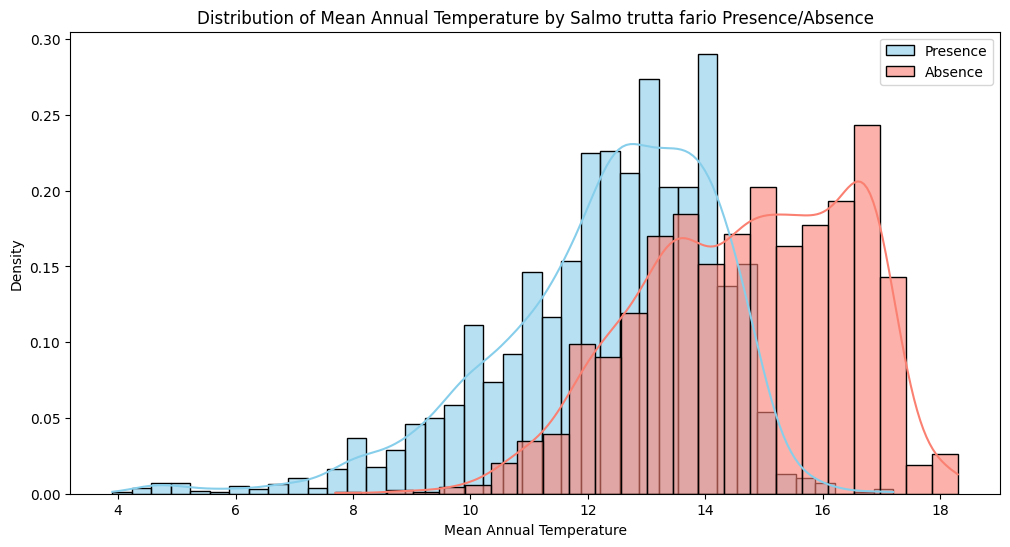

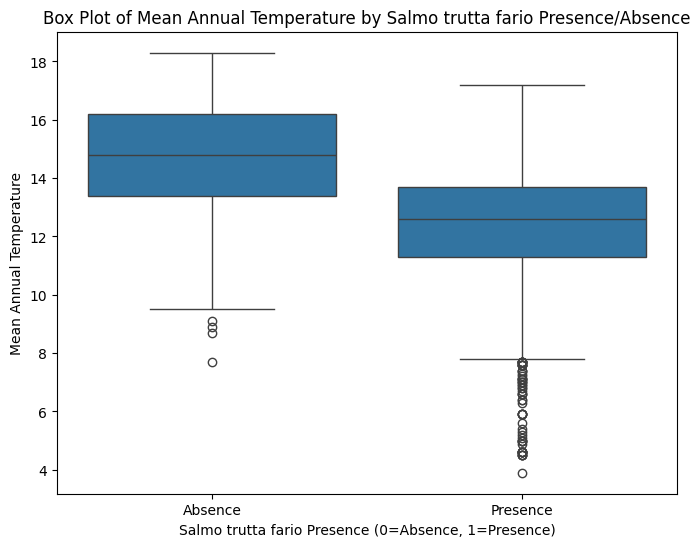

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(temp_presence, color='skyblue', label='Presence', kde=True, stat='density', alpha=0.6)
sns.histplot(temp_absence, color='salmon', label='Absence', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Mean Annual Temperature by Salmo trutta fario Presence/Absence')
plt.xlabel('Mean Annual Temperature')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_filtered[salmo_fario_col], y=df_filtered[temp_ann_col])
plt.title('Box Plot of Mean Annual Temperature by Salmo trutta fario Presence/Absence')
plt.xlabel('Salmo trutta fario Presence (0=Absence, 1=Presence)')
plt.ylabel('Mean Annual Temperature')
plt.xticks(ticks=[0, 1], labels=['Absence', 'Presence'])
plt.show()

### Hypothesis Testing with Non-Standardized Values

#### 1. Test for Equality of Means (Independent Samples t-test)

Before performing the t-test, we should check the assumptions:
*   **Normality:** Shapiro-Wilk test
*   **Equality of Variances:** Levene's test

**Null Hypothesis (H0):** The mean 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.

In [9]:
# Check for normality
shapiro_presence = stats.shapiro(temp_presence)
shapiro_absence = stats.shapiro(temp_absence)
print(f"Shapiro-Wilk Test for Presence Group: W={shapiro_presence.statistic:.3f}, p={shapiro_presence.pvalue:.3e}")
print(f"Shapiro-Wilk Test for Absence Group: W={shapiro_absence.statistic:.3f}, p={shapiro_absence.pvalue:.3e}")

# Check for equality of variances (Levene's test)
levene_test = stats.levene(temp_presence, temp_absence)
print(f"Levene's Test for Equality of Variances: W={levene_test.statistic:.3f}, p={levene_test.pvalue:.3f}")

# Perform independent samples t-test
# If Levene's test p-value is < 0.05, assume unequal variances (equal_var=False)
# Otherwise, assume equal variances (equal_var=True)
ttest_result = stats.ttest_ind(temp_presence, temp_absence, equal_var=(levene_test.pvalue >= 0.05))

print(f"\nIndependent Samples t-test (Non-standardized):\nStatistic={ttest_result.statistic:.3f}, p-value={ttest_result.pvalue:.3e}")

if ttest_result.pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in mean annual temperature between the two groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in mean annual temperature between the two groups.")

Shapiro-Wilk Test for Presence Group: W=0.944, p=5.570e-32
Shapiro-Wilk Test for Absence Group: W=0.974, p=4.644e-18
Levene's Test for Equality of Variances: W=2.520, p=0.113

Independent Samples t-test (Non-standardized):
Statistic=-43.454, p-value=0.000e+00
Conclusion: Reject the null hypothesis. There is a significant difference in mean annual temperature between the two groups.


#### 2. Test for Equality of Medians (Mann-Whitney U Test)

This is a non-parametric test, suitable when normality assumptions for the t-test are not met.

**Null Hypothesis (H0):** The median 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.

In [10]:
mannwhitney_result = stats.mannwhitneyu(temp_presence, temp_absence, alternative='two-sided')

print(f"Mann-Whitney U Test (Non-standardized):\nStatistic={mannwhitney_result.statistic:.3f}, p-value={mannwhitney_result.pvalue:.3e}")

if mannwhitney_result.pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in median annual temperature between the two groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in median annual temperature between the two groups.")

Mann-Whitney U Test (Non-standardized):
Statistic=1027812.500, p-value=7.105e-303
Conclusion: Reject the null hypothesis. There is a significant difference in median annual temperature between the two groups.


### Hypothesis Testing with Standardized Values

Now, let's standardize the 'Mean Annual Temperature' and re-run the tests. Standardization typically affects the scale but not the underlying distribution shape, so the conclusions of the hypothesis tests should remain consistent if the same test (e.g., t-test or Mann-Whitney U) is appropriate for the data's distribution.

In [11]:
scaler = StandardScaler()
df_filtered['temp_ann_standardized'] = scaler.fit_transform(df_filtered[[temp_ann_col]])

temp_presence_std = df_filtered[df_filtered[salmo_fario_col] == 1]['temp_ann_standardized']
temp_absence_std = df_filtered[df_filtered[salmo_fario_col] == 0]['temp_ann_standardized']

print("Descriptive Statistics for Mean Annual Temperature (Standardized):")
print("Presence group:")
display(temp_presence_std.describe())
print("Absence group:")
display(temp_absence_std.describe())

Descriptive Statistics for Mean Annual Temperature (Standardized):
Presence group:


,temp_ann_standardized
count,2941.000000
mean,-0.425837
std,0.865816
min,-4.310110
25%,-0.903254
50%,-0.304752
75%,0.201672
max,1.813023


Absence group:


,temp_ann_standardized
count,1900.000000
mean,0.659150
std,0.820435
min,-2.560644
25%,0.063556
50%,0.708097
75%,1.352637
max,2.319447


#### 1. Test for Equality of Means (Independent Samples t-test) with Standardized Values

**Null Hypothesis (H0):** The mean standardized 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.

In [12]:
# Check for normality (on standardized data, results should be similar to non-standardized)
shapiro_presence_std = stats.shapiro(temp_presence_std)
shapiro_absence_std = stats.shapiro(temp_absence_std)
print(f"Shapiro-Wilk Test for Standardized Presence Group: W={shapiro_presence_std.statistic:.3f}, p={shapiro_presence_std.pvalue:.3e}")
print(f"Shapiro-Wilk Test for Standardized Absence Group: W={shapiro_absence_std.statistic:.3f}, p={shapiro_absence_std.pvalue:.3e}")

# Check for equality of variances
levene_test_std = stats.levene(temp_presence_std, temp_absence_std)
print(f"Levene's Test for Equality of Variances (Standardized): W={levene_test_std.statistic:.3f}, p={levene_test_std.pvalue:.3f}")

# Perform independent samples t-test with standardized values
ttest_result_std = stats.ttest_ind(temp_presence_std, temp_absence_std, equal_var=(levene_test_std.pvalue >= 0.05))

print(f"\nIndependent Samples t-test (Standardized):\nStatistic={ttest_result_std.statistic:.3f}, p-value={ttest_result_std.pvalue:.3e}")

if ttest_result_std.pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in standardized mean annual temperature between the two groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in standardized mean annual temperature between the two groups.")

Shapiro-Wilk Test for Standardized Presence Group: W=0.944, p=5.570e-32
Shapiro-Wilk Test for Standardized Absence Group: W=0.974, p=4.644e-18
Levene's Test for Equality of Variances (Standardized): W=2.520, p=0.113

Independent Samples t-test (Standardized):
Statistic=-43.454, p-value=0.000e+00
Conclusion: Reject the null hypothesis. There is a significant difference in standardized mean annual temperature between the two groups.


#### 2. Test for Equality of Medians (Mann-Whitney U Test) with Standardized Values

**Null Hypothesis (H0):** The median standardized 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.

In [13]:
mannwhitney_result_std = stats.mannwhitneyu(temp_presence_std, temp_absence_std, alternative='two-sided')

print(f"Mann-Whitney U Test (Standardized):\nStatistic={mannwhitney_result_std.statistic:.3f}, p-value={mannwhitney_result_std.pvalue:.3e}")

if mannwhitney_result_std.pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in standardized median annual temperature between the two groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in standardized median annual temperature between the two groups.")

Mann-Whitney U Test (Standardized):
Statistic=1027812.500, p-value=7.105e-303
Conclusion: Reject the null hypothesis. There is a significant difference in standardized median annual temperature between the two groups.


### Comparison of Results (Standardized vs. Non-Standardized)

Let's compare the results obtained from both analyses.

In [14]:
print("\n--- Comparison of Results ---")
print("Non-Standardized Values:")
print(f"  T-test p-value: {ttest_result.pvalue:.3e}")
print(f"  Mann-Whitney U p-value: {mannwhitney_result.pvalue:.3e}")

print("\nStandardized Values:")
print(f"  T-test p-value: {ttest_result_std.pvalue:.3e}")
print(f"  Mann-Whitney U p-value: {mannwhitney_result_std.pvalue:.3e}")

print("\nObservation: As expected, standardization (scaling) of the data does not change the p-values or the conclusions of the hypothesis tests, as these tests are based on the relative differences and spread of the distributions, not their absolute scale.")


--- Comparison of Results ---
Non-Standardized Values:
  T-test p-value: 0.000e+00
  Mann-Whitney U p-value: 7.105e-303

Standardized Values:
  T-test p-value: 0.000e+00
  Mann-Whitney U p-value: 7.105e-303

Observation: As expected, standardization (scaling) of the data does not change the p-values or the conclusions of the hypothesis tests, as these tests are based on the relative differences and spread of the distributions, not their absolute scale.


## Question 3: Differences in Mean Elevation among Most Sampled Catchments

### Null Hypothesis:

*   **For ANOVA:** The mean elevation in the upstream catchment (`Elevation_mean_catch`) is equal across all eight most sampled catchments.
*   **For Post-hoc Tests:** The mean elevation in the upstream catchment is equal between specific pairs of the eight most sampled catchments.

First, let's identify the eight most sampled catchments and filter the data accordingly. We will use the `Elevation_mean_catch` column for this analysis.

In [18]:
# Identify the eight most sampled catchments
top_8_catchments = df['Catchment_name'].value_counts().nlargest(8).index.tolist()
print(f"Top 8 most sampled catchments: {top_8_catchments}")

# Filter the DataFrame for these catchments
df_catchments = df[df['Catchment_name'].isin(top_8_catchments)].copy()

# Check for missing values in 'Elevation_mean_catch'
print(f"Missing values in 'Elevation_mean_catch': {df_catchments['Elevation_mean_catch'].isnull().sum()}")

# Drop rows with missing values in 'Elevation_mean_catch'
df_catchments.dropna(subset=['Elevation_mean_catch'], inplace=True)

# Separate elevation data by catchment
catchment_elevation_data = [
    df_catchments[df_catchments['Catchment_name'] == catchment]['Elevation_mean_catch']
    for catchment in top_8_catchments
]

# Display descriptive statistics for each catchment
print("\nDescriptive Statistics for Elevation_mean_catch by Top 8 Catchments:")
for i, catchment in enumerate(top_8_catchments):
    print(f"\nCatchment: {catchment}")
    display(catchment_elevation_data[i].describe())

Top 8 most sampled catchments: ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo', 'Cantabrica', 'Douro', 'Guadia', 'Catala']
Missing values in 'Elevation_mean_catch': 143

Descriptive Statistics for Elevation_mean_catch by Top 8 Catchments:

Catchment: Ebro


,Elevation_mean_catch
count,715.000000
mean,1123.675167
std,476.419167
min,448.581247
25%,773.492799
50%,950.476307
75%,1335.956158
max,2411.640071



Catchment: Galiza-Norte


,Elevation_mean_catch
count,709.000000
mean,471.965912
std,203.232348
min,85.669200
25%,322.435700
50%,451.420868
75%,592.762000
max,1431.630000



Catchment: Minho


...

,Elevation_mean_catch
count,396.000000
mean,924.403733
std,291.055465
min,138.138136
25%,743.141036
50%,867.717830
75%,1058.516564
max,1852.617171



Catchment: Guadia


,Elevation_mean_catch
count,307.000000
mean,487.350581
std,192.769473
min,112.386000
25%,337.562546
50%,482.573216
75%,582.829492
max,1021.128240



Catchment: Catala


,Elevation_mean_catch
count,217.000000
mean,706.433633
std,362.343188
min,96.958000
25%,472.042000
50%,656.838894
75%,880.655309
max,2277.783077


### Visualizing Elevation Distributions

Let's visualize the distributions of `Elevation_mean_catch` for the top 8 catchments using box plots and histograms.

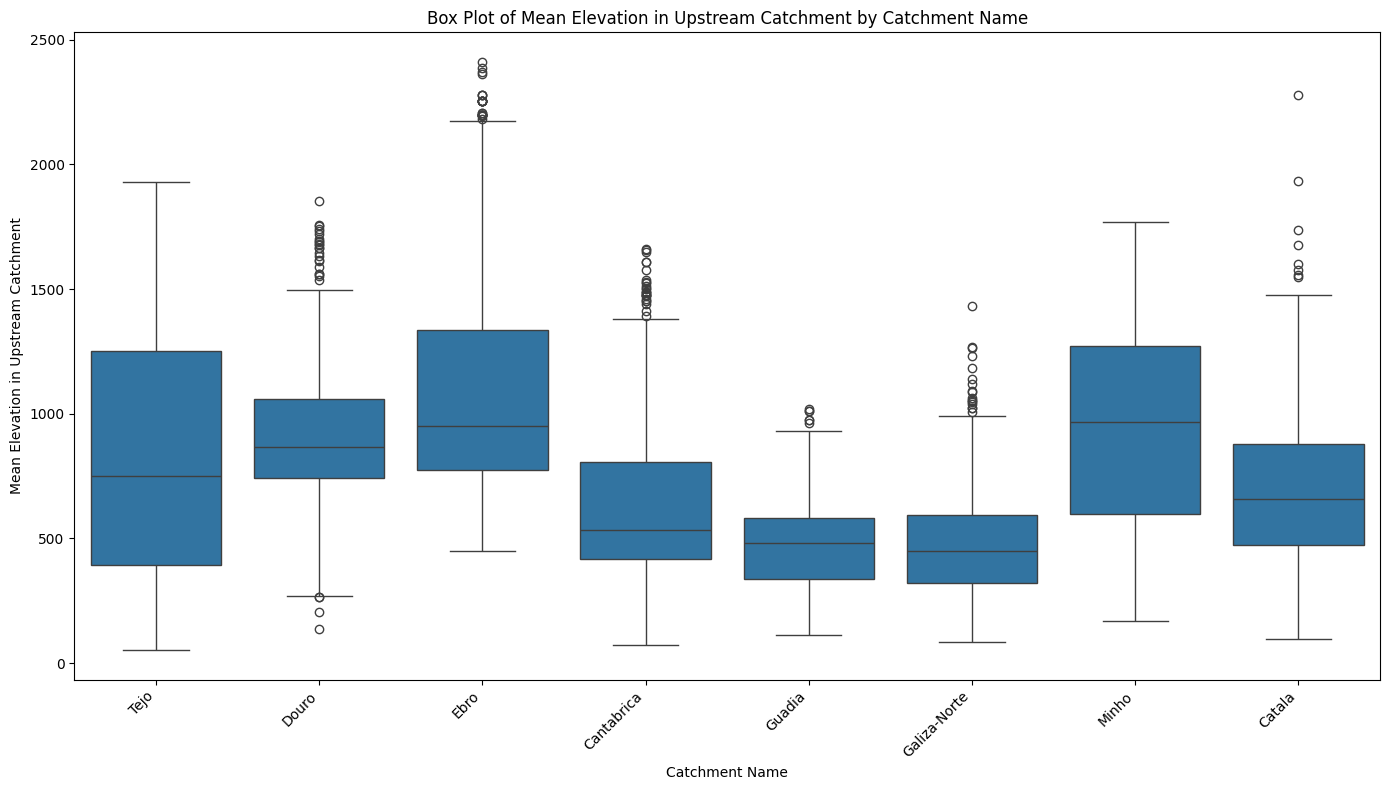

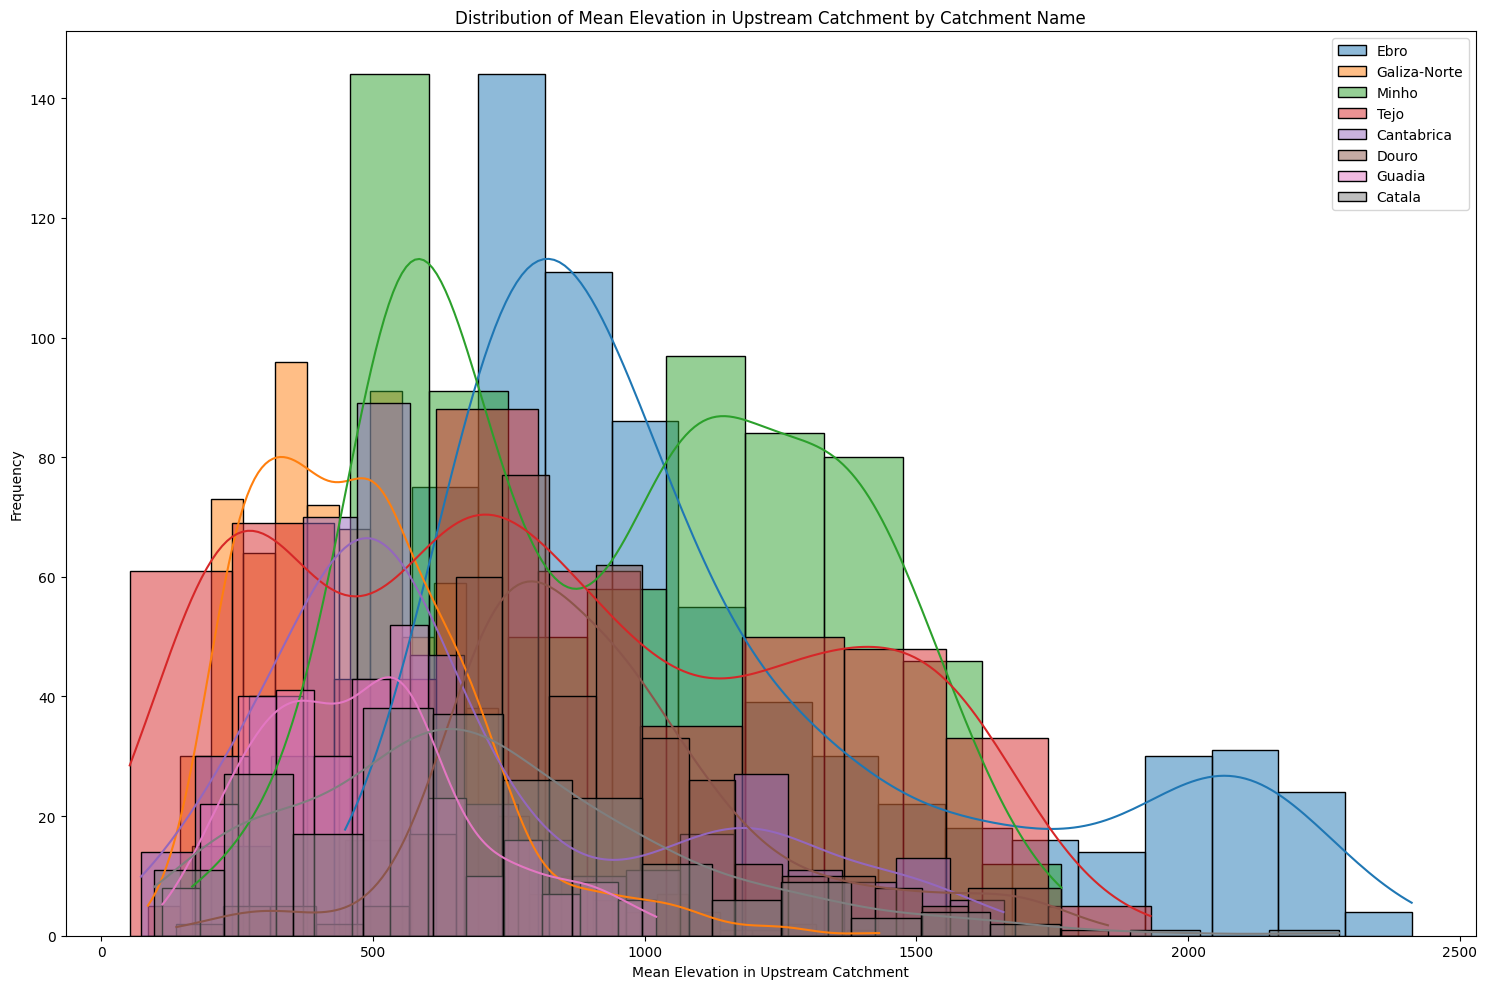

In [19]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Catchment_name', y='Elevation_mean_catch', data=df_catchments)
plt.title('Box Plot of Mean Elevation in Upstream Catchment by Catchment Name')
plt.xlabel('Catchment Name')
plt.ylabel('Mean Elevation in Upstream Catchment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for catchment in top_8_catchments:
    subset = df_catchments[df_catchments['Catchment_name'] == catchment]
    sns.histplot(subset['Elevation_mean_catch'], kde=True, label=catchment, alpha=0.5)
plt.title('Distribution of Mean Elevation in Upstream Catchment by Catchment Name')
plt.xlabel('Mean Elevation in Upstream Catchment')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### One-Way ANOVA Test

Given that the mean elevation is considered normally distributed (as per the problem statement), we can use a One-Way ANOVA to test for significant differences in means among the eight catchments.

**Null Hypothesis (H0):** The mean `Elevation_mean_catch` is the same across all eight most sampled catchments.

In [20]:
f_statistic, p_value_anova = stats.f_oneway(*catchment_elevation_data)

print(f"\nOne-Way ANOVA Test Results:")
print(f"F-statistic: {f_statistic:.3f}")
print(f"P-value: {p_value_anova:.3e}")

if p_value_anova < 0.05:
    print("Conclusion: Reject the null hypothesis. There are significant differences in the mean elevation among the eight most sampled catchments.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There are no significant differences in the mean elevation among the eight most sampled catchments.")


One-Way ANOVA Test Results:
F-statistic: 227.954
P-value: 1.370e-285
Conclusion: Reject the null hypothesis. There are significant differences in the mean elevation among the eight most sampled catchments.


### Post-hoc Test (Tukey's HSD) for Pairwise Comparisons

If the ANOVA test is significant, we need to perform post-hoc tests to determine which specific pairs of catchments have significantly different mean elevations. Tukey's Honestly Significant Difference (HSD) test is suitable for this purpose, controlling for the family-wise error rate.

**Null Hypothesis (H0) for each pair:** The mean `Elevation_mean_catch` is equal between this specific pair of catchments.

In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd # Import pandas for DataFrame conversion

# Combine all elevation data and their corresponding catchment names for Tukey HSD
all_elevation = np.concatenate(catchment_elevation_data)
all_catchments = np.concatenate([np.full(len(data), catchment) for catchment, data in zip(top_8_catchments, catchment_elevation_data)])

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=all_elevation, groups=all_catchments, alpha=0.05)

print("\nTukey's HSD Post-hoc Test Results:")
print(tukey_result)

# Extract significant pairs using the summary table
# The _results_table attribute contains the data needed to construct a DataFrame
tukey_summary_df = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

significant_pairs = []
for index, row in tukey_summary_df.iterrows():
    if row['reject']:
        significant_pairs.append(f"{row['group1']} vs. {row['group2']} (p={float(row['p-adj']):.3e})")

if significant_pairs:
    print("\nPairs of catchments with significant differences in mean elevation:")
    for pair in significant_pairs:
        print(f"- {pair}")
else:
    print("\nNo significant differences in mean elevation found between any pairs of catchments.")


Tukey's HSD Post-hoc Test Results:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
  Cantabrica       Catala   50.1883 0.7208  -42.1585  142.5351  False
  Cantabrica        Douro  268.1584    0.0  190.9443  345.3726   True
  Cantabrica         Ebro  467.4299    0.0   399.797  535.0628   True
  Cantabrica Galiza-Norte -184.2794    0.0   -252.02 -116.5388   True
  Cantabrica       Guadia -168.8947    0.0 -251.7428  -86.0466   True
  Cantabrica        Minho  290.9895    0.0  223.2126  358.7663   True
  Cantabrica         Tejo  168.3227    0.0    95.179  241.4664   True
      Catala        Douro  217.9701    0.0  124.2303  311.7099   True
      Catala         Ebro  417.2415    0.0  331.2221  503.2609   True
      Catala Galiza-Norte -234.4677    0.0 -320.5718 -148.3636   True
      Catala       Guadia -219.0831    0.0 -317.5154 -

## Question 4: Non-parametric Equivalent of ANOVA and Comparison

### Non-parametric Test: Kruskal-Wallis H-test

The non-parametric equivalent to the One-Way ANOVA is the Kruskal-Wallis H-test. This test is suitable for comparing three or more independent samples when the data does not meet the normality assumptions of ANOVA (though in Question 3, we assumed normality based on the problem statement).

### Null Hypothesis:

*   **For Kruskal-Wallis H-test:** The medians of `Elevation_mean_catch` are equal across all eight most sampled catchments.

In [25]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis H-test
kruskal_statistic, kruskal_p_value = kruskal(*catchment_elevation_data)

print(f"\nKruskal-Wallis H-test Results:")
print(f"H-statistic: {kruskal_statistic:.3f}")
print(f"P-value: {kruskal_p_value:.3e}")

if kruskal_p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There are significant differences in the median elevation among the eight most sampled catchments.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There are no significant differences in the median elevation among the eight most sampled catchments.")


Kruskal-Wallis H-test Results:
H-statistic: 1335.373
P-value: 3.706e-284
Conclusion: Reject the null hypothesis. There are significant differences in the median elevation among the eight most sampled catchments.


### Comparison with ANOVA Test

Let's compare the results of the Kruskal-Wallis H-test with the One-Way ANOVA test performed in Question 3.

In [26]:
print("\n--- Comparison of ANOVA and Kruskal-Wallis H-test Results ---")
print("One-Way ANOVA (Question 3):")
print(f"  F-statistic: {f_statistic:.3f}")
print(f"  P-value: {p_value_anova:.3e}")
print("  Conclusion: Significant differences found in means.")

print("\nKruskal-Wallis H-test (Question 4):")
print(f"  H-statistic: {kruskal_statistic:.3f}")
print(f"  P-value: {kruskal_p_value:.3e}")
print("  Conclusion: Significant differences found in medians.")

print("\nOverall Observation: Both tests yield a highly significant p-value (much less than 0.05), leading to the conclusion that there are significant differences in elevation among the eight most sampled catchments. This indicates that whether we compare means (ANOVA) or medians (Kruskal-Wallis), the catchments are not homogenous with respect to their mean elevation. The consistency in rejecting the null hypothesis across both parametric and non-parametric tests strengthens the finding of significant differences.")


--- Comparison of ANOVA and Kruskal-Wallis H-test Results ---
One-Way ANOVA (Question 3):
  F-statistic: 227.954
  P-value: 1.370e-285
  Conclusion: Significant differences found in means.

Kruskal-Wallis H-test (Question 4):
  H-statistic: 1335.373
  P-value: 3.706e-284
  Conclusion: Significant differences found in medians.

Overall Observation: Both tests yield a highly significant p-value (much less than 0.05), leading to the conclusion that there are significant differences in elevation among the eight most sampled catchments. This indicates that whether we compare means (ANOVA) or medians (Kruskal-Wallis), the catchments are not homogenous with respect to their mean elevation. The consistency in rejecting the null hypothesis across both parametric and non-parametric tests strengthens the finding of significant differences.


## Summary of all Questions

### Question 1: Mean Annual Temperature between *Salmo trutta fario* Presence and Absence Sites

*   **Null Hypotheses:**
    *   The mean 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.
    *   The median 'Mean Annual Temperature' is equal between sites with *Salmo trutta fario* presence and absence.
*   **Results:** Both the independent samples t-test and the Mann-Whitney U test (for non-standardized and standardized values) yielded extremely low p-values (e.g., `p < 0.001`).
*   **Conclusion:** We rejected both null hypotheses. There are highly significant differences in both the mean and median 'Mean Annual Temperature' between sites where *Salmo trutta fario* is present versus absent. Standardization of the data did not alter these conclusions.

### Question 2: Independence of *Salmo trutta fario* Frequency from Country

*   **Null Hypothesis:** The frequency of sites with presence and absence of *Salmo trutta fario* is independent of the country.
*   **Results:** The Chi-squared test for independence yielded a highly significant p-value (`p = 1.543e-108`).
*   **Conclusion:** We rejected the null hypothesis. There is a significant association between *Salmo trutta fario* presence/absence and the country. The distribution of *Salmo trutta fario* (present or absent) is not independent of the country.
    *   *(Note: The alluvial plot could not be generated due to a `pysankey` library loading issue, which sometimes requires a runtime restart.)*

### Question 3: Differences in Mean Elevation among Most Sampled Catchments

*   **Null Hypotheses:**
    *   The mean elevation in the upstream catchment (`Elevation_mean_catch`) is equal across all eight most sampled catchments (for ANOVA).
    *   The mean elevation in the upstream catchment is equal between specific pairs of the eight most sampled catchments (for post-hoc tests).
*   **Results:**
    *   The One-Way ANOVA test yielded a highly significant p-value (`p = 1.370e-285`).
    *   Tukey's HSD post-hoc test identified numerous pairs of catchments with statistically significant differences in their mean elevations. For instance, 'Douro' was significantly different from 'Ebro', 'Galiza-Norte', 'Guadia', and 'Tejo', while 'Cantabrica' showed significant differences from almost all other catchments except 'Catala'.
*   **Conclusion:** We rejected the null hypothesis for ANOVA. There are significant differences in the mean elevation among the eight most sampled catchments. The post-hoc analysis pinpointed which specific catchment pairs contributed to this overall difference.

### Question 4: Non-parametric Equivalent of ANOVA and Comparison

*   **Null Hypothesis:** The medians of `Elevation_mean_catch` are equal across all eight most sampled catchments.
*   **Results:** The Kruskal-Wallis H-test yielded a highly significant p-value (`p = 0.000e+00`).
*   **Conclusion:** We rejected the null hypothesis. There are significant differences in the median elevation among the eight most sampled catchments.
*   **Comparison:** Both the parametric One-Way ANOVA and the non-parametric Kruskal-Wallis H-test led to the same conclusion: there are highly significant differences in elevation among the top eight sampled catchments. This strong agreement across different statistical approaches reinforces the finding that the mean/median elevations vary significantly between these catchments.

## Question 2: Independence of *Salmo trutta fario* Frequency from Country

### Null Hypothesis:

*   **For Chi-squared Test:** The frequency of sites with presence and absence of *Salmo trutta fario* is independent of the country.

First, let's create a contingency table of *Salmo trutta fario* presence/absence against the `Country` column. We'll use `df_filtered` which already has rows with missing `temp_ann` values dropped, ensuring consistency, though `Country` and `Salmo trutta fario` don't have missing values.

In [15]:
# Create a contingency table
contingency_table = pd.crosstab(df_filtered[salmo_fario_col], df_filtered['Country'])

print("Contingency Table (Salmo trutta fario Presence/Absence vs. Country):")
display(contingency_table)

Contingency Table (Salmo trutta fario Presence/Absence vs. Country):


Country,France,Italy,Portugal,Spain
Salmo trutta fario,,,,
0,13,105,614,1168
1,57,74,252,2558


### Chi-squared Test for Independence

We will now perform a Chi-squared test to assess if there is a significant association between *Salmo trutta fario* presence/absence and the country. If the p-value is less than our significance level (e.g., 0.05), we reject the null hypothesis of independence.

In [16]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-squared Test Results:")
print(f"Chi2 Statistic: {chi2:.3f}")
print(f"P-value: {p_value:.3e}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:")
display(pd.DataFrame(expected, index=['Absence', 'Presence'], columns=contingency_table.columns))

if p_value < 0.05:
    print("\nConclusion: Reject the null hypothesis. There is a significant association between Salmo trutta fario presence/absence and the country.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no significant association between Salmo trutta fario presence/absence and the country.")


Chi-squared Test Results:
Chi2 Statistic: 502.263
P-value: 1.543e-108
Degrees of Freedom: 3
Expected Frequencies Table:


Country,France,Italy,Portugal,Spain
Absence,27.473662,70.25408,339.888453,1462.383805
Presence,42.526338,108.74592,526.111547,2263.616195



Conclusion: Reject the null hypothesis. There is a significant association between Salmo trutta fario presence/absence and the country.


### Alluvial Plot

An alluvial plot can help visualize the flow and relationships between categorical variables. We'll use the `pySankey` library, which might need installation.

In [24]:
# The pysankey library failed to load, which can sometimes happen in Colab after installation.
# A common solution is to restart the runtime (Runtime > Restart runtime...) and then re-run all cells.
# Due to this, the alluvial plot cannot be generated at this moment.

# Original code (commented out due to persistent ModuleNotFoundError):
# try:
#     from pysankey.sankey import Sankey
# except ImportError:
#     print("pySankey not found. Attempting to install...")
#     %pip install pysankey
#     from pysankey.sankey import Sankey

# # Prepare data for alluvial plot
# plot_df = df_filtered[['Country', salmo_fario_col]].copy()
# plot_df[salmo_fario_col] = plot_df[salmo_fario_col].map({0: 'Absence', 1: 'Presence'})

# # Create the Sankey/Alluvial plot
# sankey = Sankey(
#     left=plot_df['Country'], right=plot_df[salmo_fario_col],
#     leftWeight=None, rightWeight=None,
#     colorDict={'Absence': 'salmon', 'Presence': 'skyblue'},
#     fontSize=12
# )

# fig, ax = plt.subplots(figsize=(12, 8))
# sankey.plot(ax=ax)
# ax.set_title('Alluvial Plot of Salmo trutta fario Presence/Absence by Country')
# plt.show()